# Shortest paths and OD matrices

This notebook covers distance matrices and ordered node routes available for `UrbanGraph`. Distances are returned in the units of the selected edge weight: minutes for `time_min` and meters for `length_meter`. Route paths can be converted to their actual graph-edge geometries for visualization.


In [1]:
# To install IduEdu in a clean environment:
# !pip install IduEdu

OSM_ID = 1114252


In [2]:
from iduedu import get_intermodal_graph

G_intermodal = get_intermodal_graph(osm_id=OSM_ID, clip_by_territory=True)
G_intermodal.update_adjacency_matrix(weight="time_min")

sample_nodes = G_intermodal.nodes_gdf.index[:6].tolist()
source = sample_nodes[0]
destinations = sample_nodes[1:]
print(sample_nodes)


2026-09-15 13:35:28.374 | WARNING  | Removing 334 nodes outside the largest strongly connected component. Retaining 21184 of 21518 nodes.


2026-09-15 13:35:28.400 | WARNING  | Public transport nodes dropped with the smaller components: {'trolleybus': 2}


[0, 1, 2, 3, 4, 5]


## One shortest route and its geometry

`single_source_dijkstra_path` returns graph node ids in traversal order. `path_to_edges` selects the corresponding edge geometries, including curved street and public-transport segments, and keeps edge attributes such as travel time and transport type. Edge color identifies the transport type; line style identifies the origin-destination route.


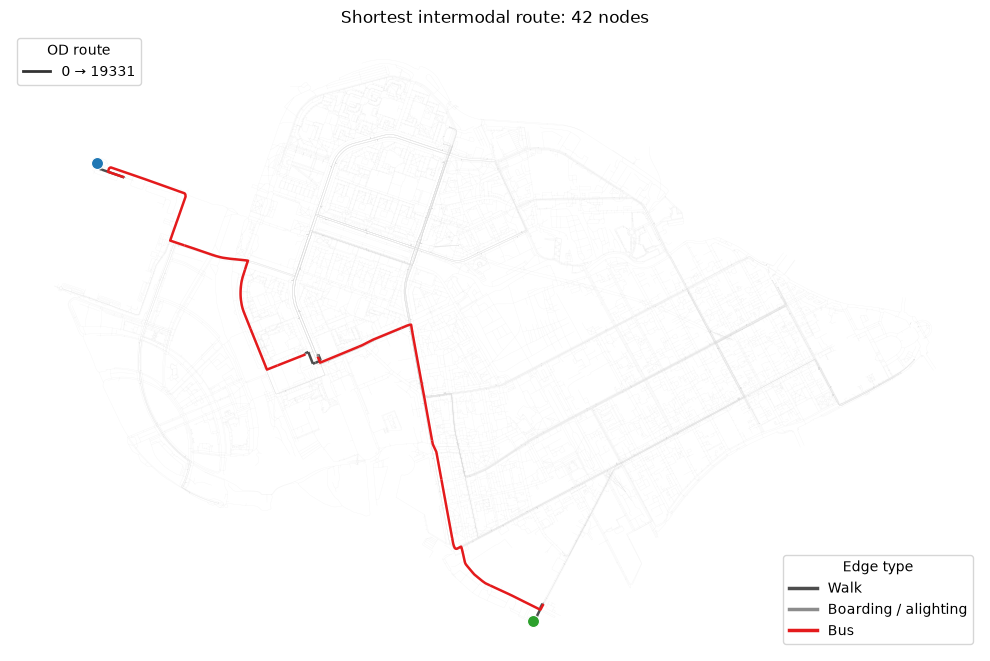

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from iduedu import path_to_edges, single_source_dijkstra_path

# Choose a distant graph node so that the resulting route is clearly visible.
source_geometry = G_intermodal.nodes_gdf.loc[source].geometry
route_target = G_intermodal.nodes_gdf.geometry.distance(source_geometry).idxmax()
node_path = single_source_dijkstra_path(
    G_intermodal,
    source,
    route_target,
    weight="time_min",
)
route_edges = path_to_edges(G_intermodal, node_path, weight="time_min")

EDGE_COLORS = {
    "walk": ("Walk", "#4d4d4d"),
    "bus": ("Bus", "#e41a1c"),
    "trolleybus": ("Trolleybus", "#984ea3"),
    "tram": ("Tram", "#ff7f00"),
    "subway": ("Subway", "#377eb8"),
    "boarding": ("Boarding / alighting", "#8c8c8c"),
    "alighting": ("Boarding / alighting", "#8c8c8c"),
    "subway_station": ("Boarding / alighting", "#8c8c8c"),
}
ROUTE_LINESTYLES = ["-", (0, (7, 3)), (0, (1, 2)), (0, (5, 2, 1, 2))]


def plot_route_by_edge_type(ax, edges, *, linestyle="-", linewidth=1.7, zorder=3):
    """Plot one OD route using edge color for mode and line style for route."""
    used_colors = {}
    for edge_type, edge_group in edges.groupby("type", sort=False, dropna=False):
        label, color = EDGE_COLORS.get(edge_type, ("Other", "#bdbdbd"))
        edge_group.plot(
            ax=ax,
            color=color,
            linewidth=linewidth,
            linestyle=linestyle,
            zorder=zorder,
        )
        used_colors[label] = color
    return used_colors


fig, ax = plt.subplots(figsize=(10, 8))
G_intermodal.edges_gdf.plot(ax=ax, color="#dddddd", linewidth=0.2, alpha=0.4, zorder=1)
used_colors = plot_route_by_edge_type(ax, route_edges, linewidth=1.8)
G_intermodal.nodes_gdf.loc[[source]].plot(
    ax=ax, color="#2ca02c", edgecolor="white", linewidth=0.8, markersize=75, zorder=5
)
G_intermodal.nodes_gdf.loc[[route_target]].plot(
    ax=ax, color="#1f77b4", edgecolor="white", linewidth=0.8, markersize=75, zorder=5
)

route_handle = Line2D([0], [0], color="#333333", linewidth=2, linestyle="-", label=f"{source} → {route_target}")
mode_handles = [
    Line2D([0], [0], color=color, linewidth=2.5, linestyle="-", label=label)
    for label, color in used_colors.items()
]
route_legend = ax.legend(handles=[route_handle], title="OD route", loc="upper left")
ax.add_artist(route_legend)
ax.legend(handles=mode_handles, title="Edge type", loc="lower right")
ax.set_title(f"Shortest intermodal route: {len(node_path)} nodes")
ax.set_axis_off()
fig.tight_layout()


## Path matrices: all-to-all and pairwise

`multi_source_dijkstra_path` accepts the same node-list or GeoDataFrame inputs as `od_matrix`. In `all_to_all` mode every matrix cell contains an ordered node route. In `pairwise` mode origin *i* is matched only with destination *i*.


In [4]:
from iduedu import multi_source_dijkstra_path

distance_rank = G_intermodal.nodes_gdf.geometry.distance(source_geometry).sort_values()
rank_positions = [len(distance_rank) // 4, len(distance_rank) // 2, 3 * len(distance_rank) // 4, -1]
matrix_origins = [source, distance_rank.index[len(distance_rank) // 10]]
matrix_destinations = distance_rank.iloc[rank_positions].index.tolist()

path_matrix = multi_source_dijkstra_path(
    G_intermodal,
    origins_nodes=matrix_origins,
    destination_nodes=matrix_destinations,
    mode="all_to_all",
    max_workers=4,
)

pairwise_paths = multi_source_dijkstra_path(
    G_intermodal,
    origins_nodes=matrix_origins,
    destination_nodes=matrix_destinations[:2],
    mode="pairwise",
    max_workers=4,
)

path_matrix


,18383,18609,14501,19331
0,"[0, 17257, 1, 3, 2, 5, 26, 27, 20146, 20403, 2...","[0, 17257, 1, 3, 2, 5, 26, 27, 20146, 20403, 2...","[0, 17257, 1, 3, 2, 5, 26, 27, 20146, 20403, 2...","[0, 17257, 1, 7, 23, 25, 20145, 20402, 20630, ..."
1622,"[1622, 1632, 1633, 2710, 2721, 2723, 2704, 272...","[1622, 1618, 1649, 1620, 20238, 20939, 20952, ...","[1622, 1618, 1649, 1620, 20238, 20937, 20950, ...","[1622, 1618, 1617, 1616, 1568, 1583, 1566, 156..."


### Visualize several matrix routes

Each non-empty matrix cell can be passed directly to `path_to_edges`. The plot below overlays all routes from the first origin to the selected destinations. Colors distinguish transport types, while solid and dashed patterns distinguish OD routes.


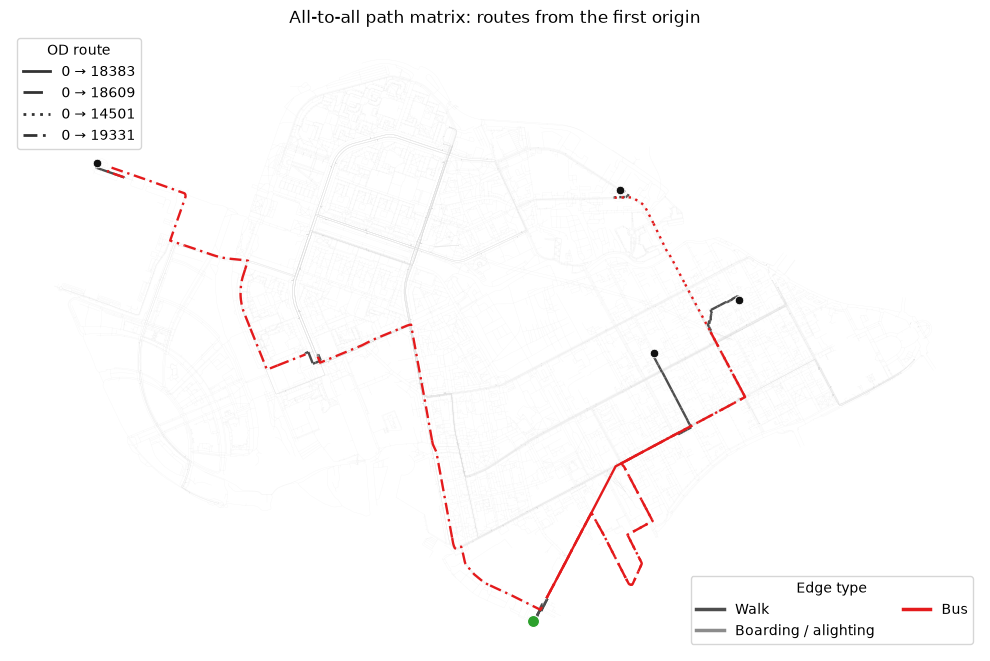

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
G_intermodal.edges_gdf.plot(ax=ax, color="#dddddd", linewidth=0.2, alpha=0.35, zorder=1)

first_origin = path_matrix.index[0]
route_handles = []
all_used_colors = {}
for linestyle, destination in zip(ROUTE_LINESTYLES, path_matrix.columns):
    path = path_matrix.loc[first_origin, destination]
    if isinstance(path, list):
        edges = path_to_edges(G_intermodal, path)
        all_used_colors.update(plot_route_by_edge_type(ax, edges, linestyle=linestyle, linewidth=1.7))
        route_handles.append(
            Line2D(
                [0], [0], color="#333333", linewidth=2, linestyle=linestyle, label=f"{first_origin} → {destination}"
            )
        )

G_intermodal.nodes_gdf.loc[[first_origin]].plot(
    ax=ax, color="#2ca02c", edgecolor="white", linewidth=0.8, markersize=75, zorder=5
)
G_intermodal.nodes_gdf.loc[path_matrix.columns].plot(
    ax=ax, color="#111111", edgecolor="white", linewidth=0.6, markersize=38, zorder=5
)
mode_handles = [
    Line2D([0], [0], color=color, linewidth=2.5, linestyle="-", label=label)
    for label, color in all_used_colors.items()
]
route_legend = ax.legend(handles=route_handles, title="OD route", loc="upper left")
ax.add_artist(route_legend)
ax.legend(handles=mode_handles, title="Edge type", loc="lower right", ncol=2)
ax.set_title("All-to-all path matrix: routes from the first origin")
ax.set_axis_off()
fig.tight_layout()


## Single-source distances

Use this for one origin and many possible destinations, for example an intermodal travel-time catchment around one point.


In [6]:
from iduedu import single_source_dijkstra_path_length

single = single_source_dijkstra_path_length(
    G_intermodal,
    source,
    weight="time_min",
    cutoff=15,
)

single.sort_values().head(10)


node
0          0.0
17257    0.151
8        0.612
9        0.972
1        1.413
3        1.472
7         1.48
6        1.491
10       1.523
2        1.549
Name: dist, dtype: Sparse[float32, inf]

## Multi-source distance to the closest source

All sources are inserted into one Dijkstra queue. The result gives the distance to the nearest source, not one row per source.


In [7]:
from iduedu import multi_source_dijkstra_path_length

multi = multi_source_dijkstra_path_length(
    G_intermodal,
    source_nodes=sample_nodes[:3],
    weight="time_min",
    cutoff=15,
)

multi.sort_values().head(10)


node
0          0.0
2          0.0
1          0.0
3        0.059
7        0.067
6        0.078
5        0.144
17257    0.151
26       0.213
23       0.217
Name: dist, dtype: Sparse[float32, inf]

## Nearest source label and distance

Use this when the winning source node is needed along with the shortest distance.


In [8]:
from iduedu import multi_source_dijkstra_nearest_source

nearest = multi_source_dijkstra_nearest_source(
    G_intermodal,
    source_nodes=sample_nodes[:3],
    weight="time_min",
    cutoff=15,
)

nearest.head(10)


,source_node,dist
node,,
0,0,0.0
1,1,0.0
2,2,0.0
3,1,0.059
4,2,1.61
5,2,0.144
6,1,0.078
7,1,0.067
8,0,0.612


## Independent parallel searches

`dijkstra_path_length_parallel` keeps one sparse row per source. This is useful when each origin needs its own accessibility profile.


In [9]:
from iduedu import dijkstra_path_length_parallel

parallel = dijkstra_path_length_parallel(
    G_intermodal,
    source_nodes=sample_nodes[:3],
    weight="time_min",
    cutoff=15,
    max_workers=4,
)

parallel.iloc[:, :8]


node,0,1,2,3,4,5,6,7
0,0.0,1.413,1.549,1.472,3.159,1.693,1.491,1.48
1,1.413,0.0,0.136,0.059,1.746,0.28,0.078,0.067
2,1.549,0.136,0.0,0.077,1.61,0.144,0.153,0.203


## Origin-destination matrix

`od_matrix` accepts graph node ids or GeoDataFrames. With node ids, rows follow `origins_nodes` and columns follow `destination_nodes`.


In [10]:
from iduedu import od_matrix

od = od_matrix(
    G_intermodal,
    origins_nodes=sample_nodes[:3],
    destination_nodes=destinations,
    weight="time_min",
    threshold=30,
    max_workers=4,
)

od


,1,2,3,4,5
0,1.413,1.549,1.472,3.159,1.693
1,0.0,0.136,0.059,1.746,0.28
2,0.136,0.0,0.077,1.61,0.144


## Method equivalents

The same helpers are also available as `UrbanGraph` methods.


In [11]:
G_intermodal.single_source_dijkstra_path(source, destinations[0], cutoff=15)
G_intermodal.multi_source_dijkstra_path(origins_nodes=sample_nodes[:2], destination_nodes=destinations, threshold=30)
G_intermodal.path_to_edges(node_path).head()
G_intermodal.single_source_dijkstra_path_length(source, cutoff=15).head()
G_intermodal.multi_source_dijkstra_path_length(source_nodes=sample_nodes[:3], cutoff=15).head()
G_intermodal.multi_source_dijkstra_nearest_source(source_nodes=sample_nodes[:3], cutoff=15).head()
G_intermodal.dijkstra_path_length_parallel(source_nodes=sample_nodes[:3], cutoff=15, max_workers=4).iloc[:, :5]
G_intermodal.od_matrix(origins_nodes=sample_nodes[:3], destination_nodes=destinations, threshold=30)


,1,2,3,4,5
0,1.413,1.549,1.472,3.159,1.693
1,0.0,0.136,0.059,1.746,0.28
2,0.136,0.0,0.077,1.61,0.144
